1. Create a simple Agent:

In [ ]:
# pip install strands-agents strands-agents-tools

from strands import Agent

# Initialize your agent
agent = Agent(
    system_prompt="You are a helpful assistant that provides concise responses."
)

# Send a message to the agent
response = agent("Hello! What can you do?")
print(response)

2. Add Tools to the Agent:

In [ ]:
from strands import Agent, tool
from strands_tools import calculator

@tool
def weather():
    """ Get weather """ # Dummy implementation
    return "sunny"

agent = Agent(
    tools=[calculator, weather],
    system_prompt="You're a helpful assistant. You can do simple math calculation, and tell the weather.")

response = agent("What is the weather today?")

print(response)

# For some applications it is important to directly call the tool. For instance, you might want to debug the tool, 
# pre-populate the agent knowledge with your customer's information or using a tool inside of another tool. 
# In Strands you can do it using the tool method of your agent followed by the tool name.You can invoke the tool 
# directly like so:

# Calculate derivative
agent.tool.calculator(expression="sin(x)", mode="derive", wrt="x", order=2)

3. Changing the log level and format:

In [ ]:
import logging
from strands import Agent

# Enables Strands debug log level
logging.getLogger("strands").setLevel(logging.DEBUG) # or logging.ERROR

# Sets the logging format and streams logs to stderr
logging.basicConfig(
    format="%(levelname)s | %(name)s | %(message)s",
    handlers=[logging.StreamHandler()]
)

agent = Agent()
agent("Hello!")

4. Model Provider
Strands Agents supports several model providers beyond Amazon Bedrock:

Anthropic - Direct API access to Claude models
LiteLLM - Unified interface for OpenAI, Mistral, and other providers
Llama API - Access to Meta's Llama models
Ollama - Run models locally for privacy or offline use
OpenAI - Direct API access to OpenAI or OpenAI-compatible models
Custom Providers - Build your own provider for specialized needs

The default model provider is Amazon Bedrock  and the default model is Claude 4 Sonnet in the region of your AWS configuration.

You can specify a different model in Amazon Bedrock providing the model ID string directly :

In [ ]:
from strands import Agent

agent = Agent(model="us.anthropic.claude-haiku-4-5-20251001-v1:0")
print(agent.model.config)

# For more control over the model configuration, you can create a BedrockModel provider instance:

import boto3
from strands import Agent
from strands.models import BedrockModel

# Create a BedrockModel
bedrock_model = BedrockModel(
    model_id="us.anthropic.claude-haiku-4-5-20251001-v1:0",
    region_name='us-west-2',
    temperature=0.3,
)

agent = Agent(model=bedrock_model)

Example: Task-Specific Agent
Here's a practical example of a task-specific agent. Here we create a RecipeBot that recommends recipes and answers any cooking related questions.

First we install the duckduckgo-search  package for a free and opensource web-search API.

Now lets build this agent:

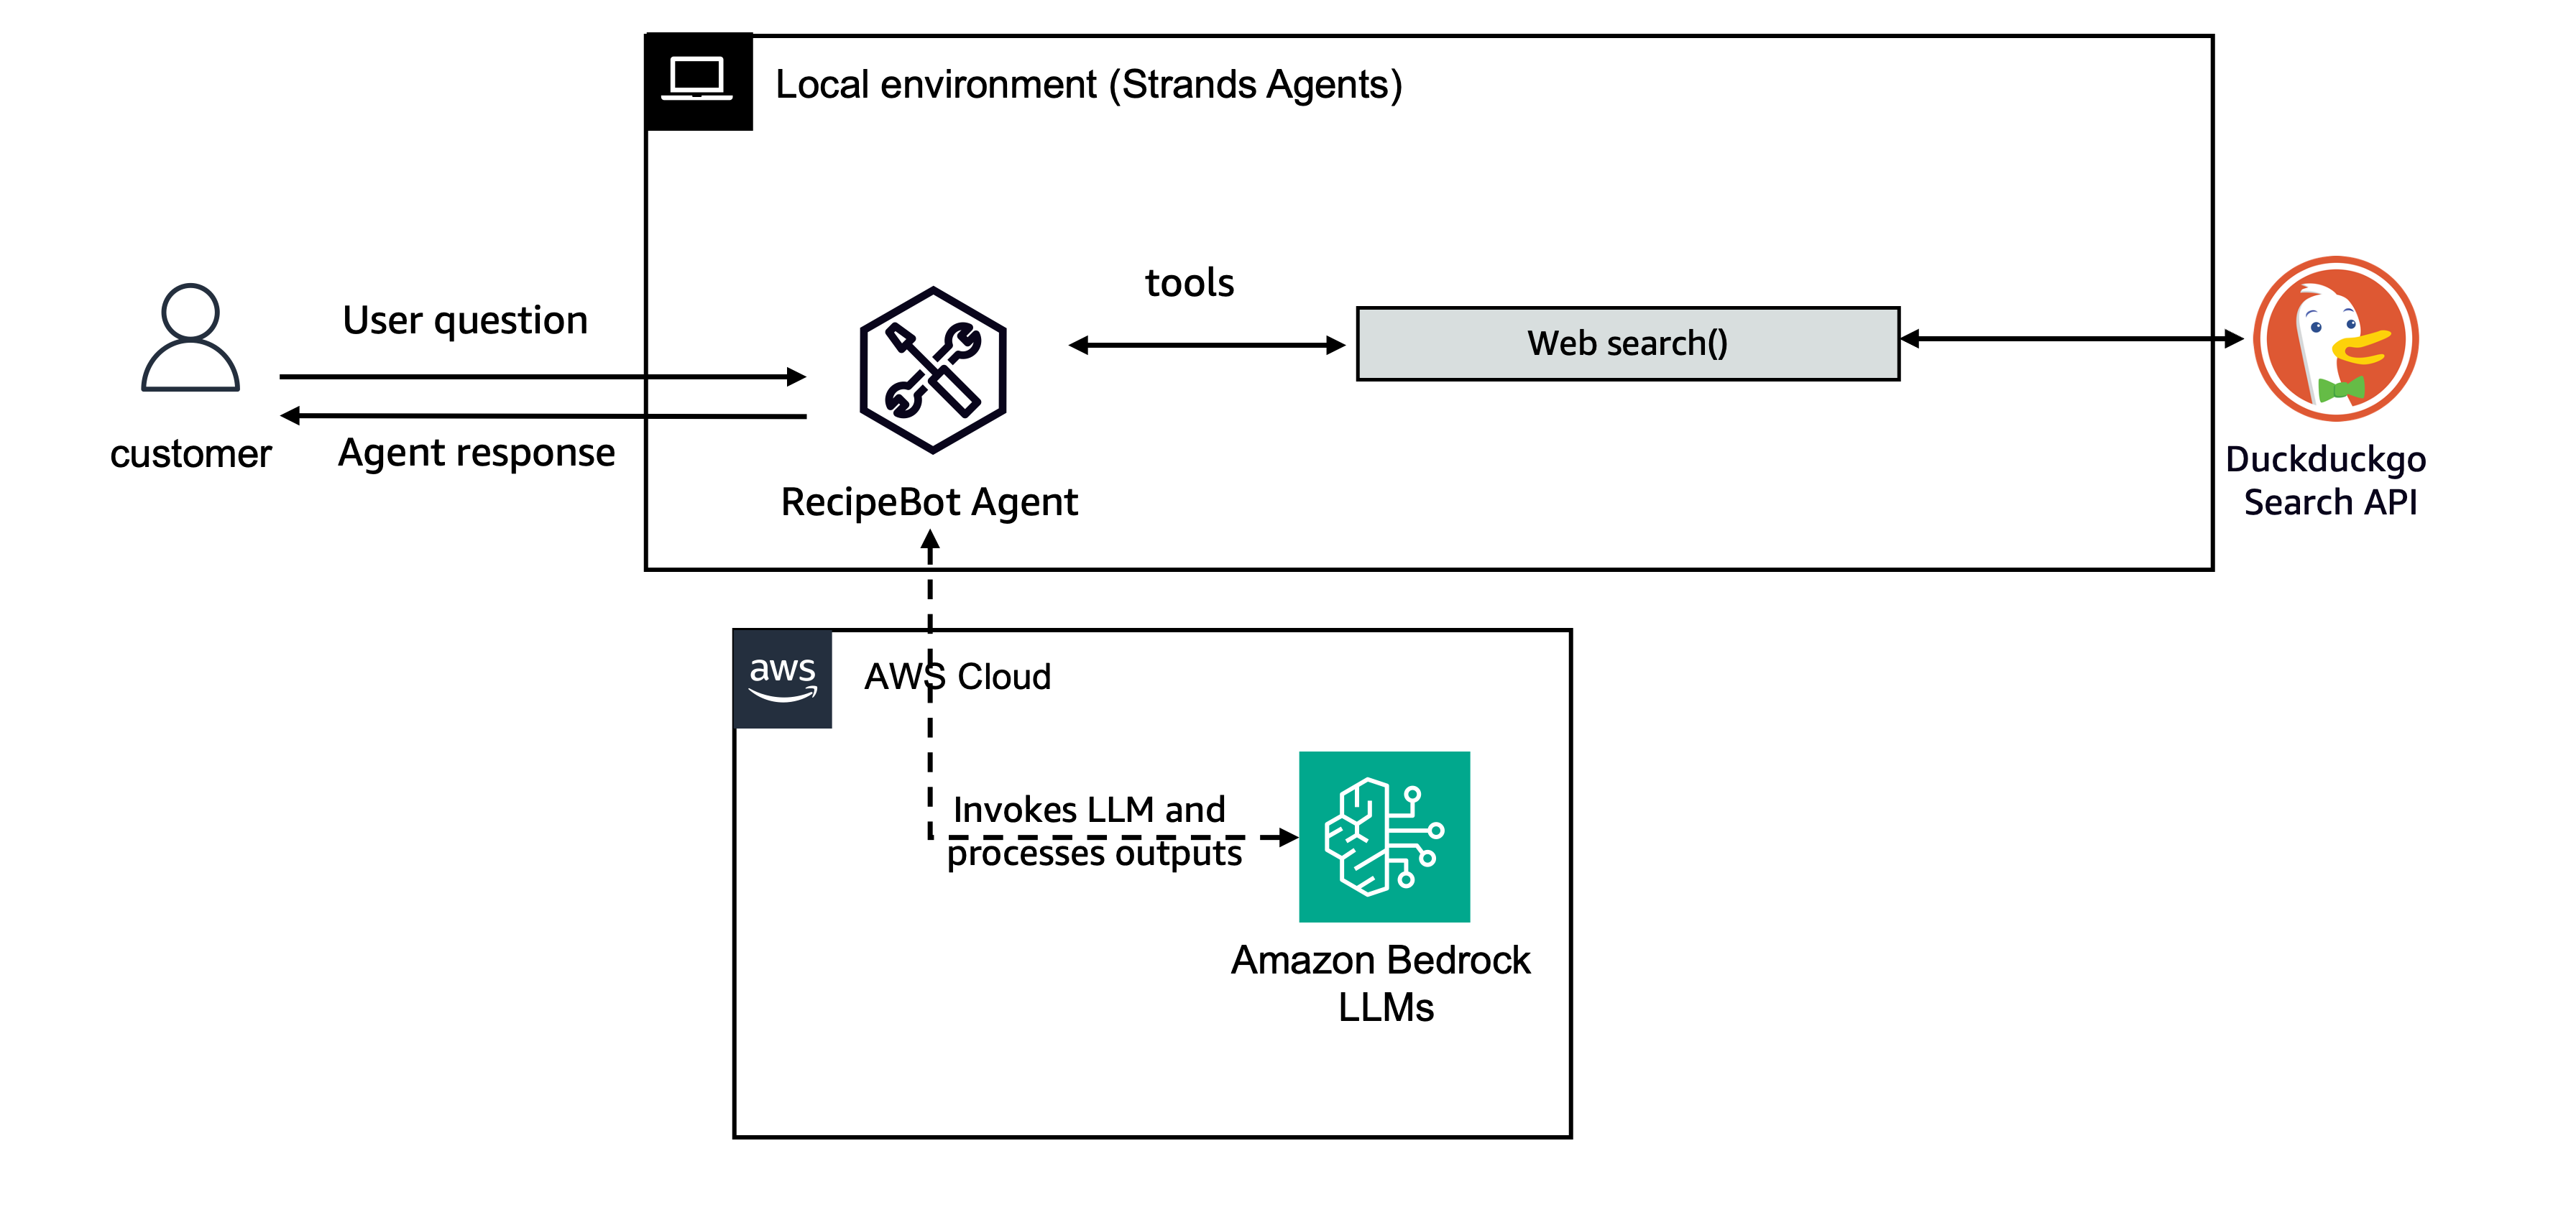

In [ ]:
from strands import Agent, tool
from duckduckgo_search import DDGS
from duckduckgo_search.exceptions import RatelimitException, DuckDuckGoSearchException
import logging

# Configure logging
logging.getLogger("strands").setLevel(logging.INFO)

# Define a websearch tool
@tool
def websearch(keywords: str, region: str = "us-en", max_results: int | None = None) -> str:
    """Search the web to get updated information.
    Args:
        keywords (str): The search query keywords.
        region (str): The search region: wt-wt, us-en, uk-en, ru-ru, etc..
        max_results (int | None): The maximum number of results to return.
    Returns:
        List of dictionaries with search results.
    """
    try:
        results = DDGS().text(keywords, region=region, max_results=max_results)
        return results if results else "No results found."
    except RatelimitException:
        return "RatelimitException: Please try again after a short delay."
    except DuckDuckGoSearchException as d:
        return f"DuckDuckGoSearchException: {d}"
    except Exception as e:
        return f"Exception: {e}"

# Create a recipe assistant agent
recipe_agent = Agent(
    system_prompt="""You are RecipeBot, a helpful cooking assistant.
    Help users find recipes based on ingredients and answer cooking questions.
    Use the websearch tool to find recipes when users mention ingredients or to look up cooking information.""",
    tools=[websearch], # Import the websearch tool we created above
)

response = recipe_agent("Suggest a recipe with chicken and broccoli.")

print(f"Metrics : {response.metrics}") # Optional, but recommended.